### [문제 인식] 닿지 않는 공간을 처음으로 인식하다  
#### Python을 활용한 공간데이터 전처리

이 강의는 공간 데이터 분석의 출발점으로, “공간을 숫자로 인식하는 방법”을 처음 배우는 세션이다.  
행정동 경계, 인구 데이터, 버스정류장과 지하철역 위치 정보를 Python과 GeoPandas로 불러와 하나의 분석용 데이터셋으로 정제하는 과정을 다룬다.

단순히 파일을 읽는 수준을 넘어서, 좌표계(CRS) 통일, 공간조인, 행정동 단위 집계 등 실제 공간 분석에 필요한 전처리 전 과정을 실습한다.  
특히 “정류장은 어디에 몰려 있고, 어떤 지역은 상대적으로 비어 있는가?”라는 질문을 데이터로 처음 확인하는 단계이다.

이 강의를 통해 수강생은 다음과 같은 흐름을 이해하게 된다.  
원시 데이터 → 좌표 기반 포인트 생성 → 행정동 경계와 공간조인 → 행정동별 시설 수 집계 → 단계구분도 시각화.

최종적으로는 행정동별 버스·지하철 접근성 분포를 지도 위에서 직접 확인하며,  
이후 강의에서 진행할 커버리지 분석과 취약지역 탐색의 기초 데이터를 완성한다.

### Pandas
- 표 형태(DataFrame)의 데이터를 효율적으로 불러오고 정리하는 데이터 분석 라이브러리  
- 결측치 처리, 정렬, 그룹 집계, 병합 등 기본 EDA 작업에 가장 많이 사용됨  
- CSV·엑셀·데이터베이스 등 다양한 데이터 포맷을 지원  
- 수치·범주형 데이터 중심의 일반 데이터 분석에 적합  

### GeoPandas
- Pandas에 공간 정보(geometry)를 결합한 공간 데이터 전용 라이브러리  
- shp·geojson 등 GIS 파일을 바로 읽고 지도 형태로 시각화 가능  
- 좌표계(CRS) 변환, 공간조인, 버퍼·면적·거리 계산 등 공간 연산 제공  
- 행정구역, 교통, 환경 등 공간 기반 분석에 특화됨  

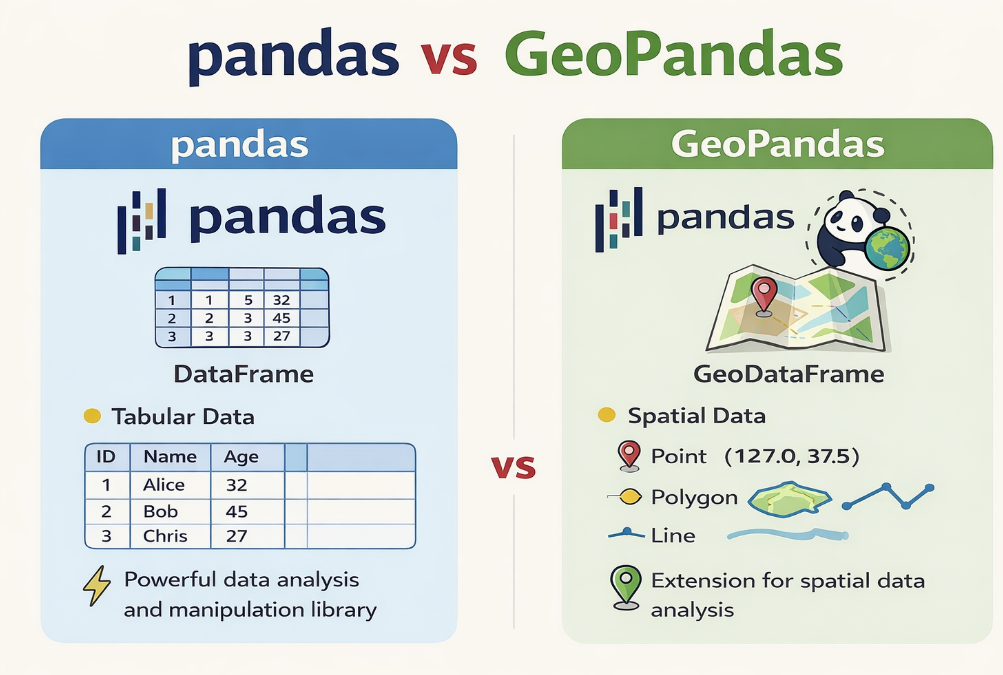

In [88]:
# GeoPandas 라이브러리 설치

%pip install geopandas

Note: you may need to restart the kernel to use updated packages.


In [89]:
import os              # 파일·폴더 경로 처리용
import warnings        # 경고 메시지 제어용
warnings.filterwarnings("ignore")  # 불필요한 경고 숨기기

import pandas as pd    # 표 형태 데이터 처리
import numpy as np     # 수치 계산 처리
import matplotlib.pyplot as plt  # 그래프 시각화
import geopandas as gpd  # 공간(지도) 데이터 처리

In [90]:
import matplotlib.font_manager as fm
import matplotlib as mpl

try:
    mpl.rcParams["font.family"] = "Malgun Gothic"   # Windows
except:
    mpl.rcParams["font.family"] = "AppleGothic"    # Mac

mpl.rcParams["axes.unicode_minus"] = False

### 0. 폴더 구조 설정 

#### 데이터 출처
- 인구 데이터 : https://data.seoul.go.kr/dataList/10043/S/2/datasetView.do
- 버스정류장 위치정보 데이터 : https://data.seoul.go.kr/dataList/OA-15067/S/1/datasetView.do
- 지하철역 위치정보 데이터 : https://www.data.go.kr/data/15099316/fileData.do 
- 행정동 벡터 데이터 : https://www.vworld.kr/dtmk/dtmk_ntads_s002.do?svcCde=MK&dsId=30017

In [91]:
BASE_DIR = os.getcwd()                     # 현재 작업 중인 기본 폴더 경로

DATA_DIR = os.path.join(BASE_DIR, "data")  # 데이터 저장 폴더
OUT_DIR  = os.path.join(BASE_DIR, "outputs")  # 결과 파일 저장 폴더

os.makedirs(DATA_DIR, exist_ok=True)       # data 폴더가 없으면 생성
os.makedirs(OUT_DIR, exist_ok=True)        # outputs 폴더가 없으면 생성

### 1. 유틸 함수 설정

In [92]:
def read_csv_safely(path):
    # CSV 파일을 UTF-8 인코딩으로 먼저 읽어본다
    try:
        return pd.read_csv(path, encoding="utf-8")
    # UTF-8로 읽지 못하면 (한글 파일일 가능성 높음) CP949 인코딩으로 다시 시도
    except UnicodeDecodeError:
        return pd.read_csv(path, encoding="cp949")

In [93]:
def to_num(s):
    # 문자열이나 섞여 있는 값을 숫자형으로 변환하고, 변환할 수 없는 값은 NaN(결측치)로 처리
    return pd.to_numeric(s, errors="coerce")

In [94]:
def norm_nm(x):
    if pd.isna(x):
        return None

    s = str(x).strip()
    s = s.replace("\u00A0", " ")
    s = " ".join(s.split())

    # '.' ↔ '·' 통일 (종로1.2.3.4가동 → 종로1·2·3·4가동)
    s = s.replace(".", "·")

    return s

In [95]:
def ensure_crs(gdf, epsg):
    # GeoDataFrame에 좌표계(CRS)가 설정되어 있는지 확인
    if gdf.crs is None:
        raise ValueError("행정동 경계 레이어 CRS 없음")

    # 지정한 EPSG 좌표계로 변환하여 반환
    return gdf.to_crs(epsg=epsg)

### 2. Shp 파일로 구성된 공간 데이터 전처리  
#### 행정동 경계 벡터 데이터를 통한 면적 계산

이 단계에서는 행정동 경계가 저장된 Shapefile 벡터 데이터를 불러와 공간 분석에 사용할 수 있는 형태로 정제한다.  
행정동 코드와 행정동 이름을 표준 컬럼으로 정리하고, 좌표계를 한국 표준 투영 좌표계(EPSG:5179)로 변환하여 면적 계산이 가능한 상태로 만든다.

특히 위경도 좌표계(EPSG:4326)는 각도 단위이기 때문에 면적 계산에 부적합하므로,  
반드시 미터 단위 좌표계로 변환한 후 각 행정동 폴리곤의 실제 면적을 계산한다.  
이렇게 계산된 면적 정보는 이후 인구밀도, 시설 밀도, 접근성 지표를 생성하는 데 핵심적인 기준 변수로 활용된다.

이 과정에서 수강생은 GeoPandas를 이용해 벡터 데이터를 읽고,  
좌표계를 확인·변환하고, geometry 연산을 통해 면적을 산출하는 공간 전처리의 기본 흐름을 익히게 된다.  
또한 행정동 단위 분석에서 “공간 크기”가 왜 중요한 기준이 되는지도 함께 이해하게 된다.

In [96]:
ADMIN_VEC = os.path.join(DATA_DIR, "BND_ADM_DONG_PG.shp")  # 행정동 경계 벡터 파일 경로

ADMIN_COL_ID = "ADM_CD"   # 행정동 코드 컬럼명
ADMIN_COL_NM = "ADM_NM"   # 행정동 이름 컬럼명

In [97]:
gdf_admin = gpd.read_file(ADMIN_VEC) # 행정동 경계 벡터 파일(shp)을 GeoDataFrame으로 읽기
gdf_admin = gdf_admin[[ADMIN_COL_ID, ADMIN_COL_NM, "geometry"]].copy() # 필요한 컬럼(행정동 코드, 행정동 이름, 도형)만 선택해서 복사
gdf_admin.rename(columns={ADMIN_COL_ID: "region_id", ADMIN_COL_NM: "region_nm"}, inplace=True) # 컬럼 이름을 표준 형식(region_id, region_nm)으로 변경

In [98]:
gdf_admin["region_id"] = gdf_admin["region_id"].astype(str) # 행정동 코드를 문자열로 변환 (앞자리 코드 비교를 하기 위해) 
gdf_admin = gdf_admin[gdf_admin["region_id"].str.startswith("11")].copy() # 행정동 코드가 '11'로 시작하는 행만 선택 → 서울특별시에 해당하는 행정동만 남김
gdf_admin.head()

,region_id,region_nm,geometry
69,11240750,잠실4동,"POLYGON ((210330.09 547163.722, 210326.158 547..."
552,11240780,잠실7동,"POLYGON ((206502.446 544771.474, 206494.684 54..."
734,11240790,잠실2동,"POLYGON ((207564.725 545798.428, 207564.263 54..."
847,11240770,잠실6동,"POLYGON ((208949.521 547174.423, 208975.386 54..."
917,11240580,방이2동,"POLYGON ((209981.565 546446.632, 210067.824 54..."


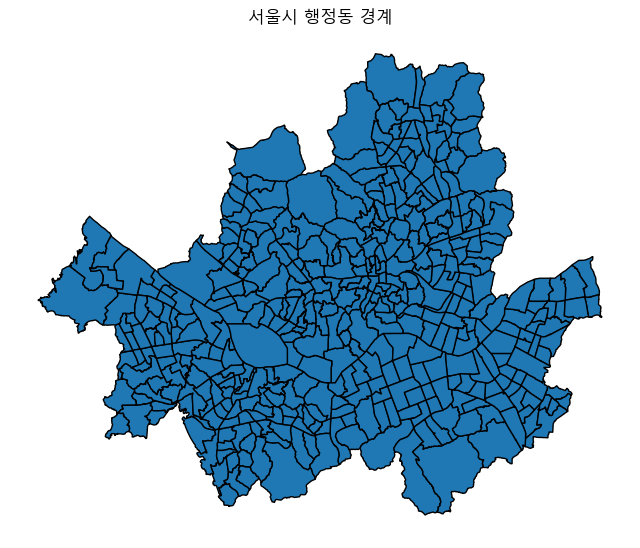

In [99]:
gdf_admin.plot(figsize=(8, 8), edgecolor="black")
plt.title("서울시 행정동 경계")
plt.axis("off")
plt.show()

In [100]:
# 행정동 이름을 표준화 함수(norm_nm)로 정리(공백·특수문자·표기 차이를 통일하여 이후 데이터 매칭 정확도 향상)
gdf_admin["region_nm"] = gdf_admin["region_nm"].map(norm_nm)  

In [101]:
# 행정동 경계 데이터를 미터 단위 좌표계(EPSG:5179, Korea 2000 / Central Belt)로 변환
# 이후 면적 계산, 거리·버퍼 분석, 공간조인을 모두 같은 좌표계에서 처리하기 위함
gdf_admin = ensure_crs(gdf_admin, 5179)

In [102]:
area_df = gdf_admin[["region_id", "region_nm"]].copy() # 행정동 코드(region_id)와 행정동 이름(region_nm)을 함께 추출하여 면적 테이블 생성
area_df["area_km2"] = gdf_admin.geometry.area / 1e6 # 각 행정동 폴리곤의 면적을 계산한 뒤 m² → km² 단위로 변환하여 저장
area_df.head()

,region_id,region_nm,area_km2
69,11240750,잠실4동,0.779601
552,11240780,잠실7동,0.722932
734,11240790,잠실2동,2.684790
847,11240770,잠실6동,1.506839
917,11240580,방이2동,0.769245


In [103]:
AREA_FILE = os.path.join(DATA_DIR, "area_by_admin.csv")  # 행정동별 면적 정보를 저장할 CSV 파일 경로 설정
area_df.to_csv(AREA_FILE, index=False, encoding="utf-8-sig") # 행정동별 면적 테이블을 CSV 파일로 저장 (한글 깨짐 방지를 위해 utf-8-sig 인코딩 사용)

### 3. 일반 CSV 데이터 전처리  
#### 인구데이터 처리

이 단계에서는 행정동별 등록인구가 포함된 일반 CSV 데이터를 불러와 분석에 적합한 형태로 정제한다.  
다단 헤더 구조로 구성된 원본 파일에서 행정동 이름, 남자 인구, 여자 인구 컬럼을 정확히 추출하고,  
문자열로 저장된 수치 데이터를 숫자형으로 변환하여 계산이 가능한 상태로 만든다.

남자와 여자 인구를 합산하여 총인구(`population`) 변수를 생성하고,  
행정동 이름을 기준으로 행정동 경계 데이터와 매칭할 수 있도록 표기 방식과 공백, 특수문자를 정규화한다.  
이를 통해 서로 다른 출처의 데이터라도 동일한 행정동 단위로 정확히 결합할 수 있게 된다.

정제된 인구 데이터는 이후 면적 정보와 결합되어 인구밀도 지표를 생성하는 데 활용되며,  
버스·지하철 시설 분포와 비교 분석을 수행하는 핵심 기초 변수 역할을 한다.  

In [104]:
POP_CSV = os.path.join(DATA_DIR, "등록인구_20260126112616.csv") # 등록인구 원본 CSV 파일 경로 설정

pop_raw = pd.read_csv(POP_CSV, header=[0, 1, 2]) # 다단 헤더(3줄)를 가진 등록인구 CSV 파일을 읽기
pop_raw.head()

동별(1) 동별(2) 동별(3) 2025 4/4                                               \
  동별(1) 동별(2) 동별(3)  세대 (세대)    계 (명)                    한국인 (명)            
  동별(1) 동별(2) 동별(3)       소계       소계       남자       여자       소계       남자   
0    합계    소계    소계  4501031  9579177  4601282  4977895  9299548  4481099   
1    합계   종로구    소계    72324   148813    70635    78178   137048    65668   
2    합계   종로구   사직동     4584     9139     4036     5103     8898     3898   
3    합계   종로구   삼청동     1065     2353     1132     1221     2114     1004   
4    합계   종로구   부암동     4109     9170     4273     4897     8926     4169   

                                                             
           등록외국인 (명)                 세대당인구 (명) 65세이상고령자 (명)  
        여자        소계      남자      여자        소계           소계  
0  4818449    279629  120183  159446      2.07      1912751  
1    71380     11765    4967    6798      1.89        30958  
2     5000       241     138     103      1.94         1984  
3     1110       239     128     111      1.98          641  
4     4757       244     104     140      2.17         2046

In [105]:
cols = pop_raw.columns # 읽어온 데이터의 전체 컬럼 구조(다중 컬럼 인덱스)를 확인하기 위해 컬럼 목록 저장
cols

MultiIndex([(   '동별(1)',        '동별(1)', '동별(1)'),
            (   '동별(2)',        '동별(2)', '동별(2)'),
            (   '동별(3)',        '동별(3)', '동별(3)'),
            ('2025 4/4',      '세대 (세대)',    '소계'),
            ('2025 4/4',        '계 (명)',    '소계'),
            ('2025 4/4',        '계 (명)',    '남자'),
            ('2025 4/4',        '계 (명)',    '여자'),
            ('2025 4/4',      '한국인 (명)',    '소계'),
            ('2025 4/4',      '한국인 (명)',    '남자'),
            ('2025 4/4',      '한국인 (명)',    '여자'),
            ('2025 4/4',    '등록외국인 (명)',    '소계'),
            ('2025 4/4',    '등록외국인 (명)',    '남자'),
            ('2025 4/4',    '등록외국인 (명)',    '여자'),
            ('2025 4/4',    '세대당인구 (명)',    '소계'),
            ('2025 4/4', '65세이상고령자 (명)',    '소계')],
           )

In [106]:
dong_col   = [c for c in cols if "동별(3)" in str(c)][0] # 다단 헤더 컬럼 중에서 '동별(3)'이 포함된 컬럼을 찾아 행정동 이름 컬럼으로 선택
male_col   = [c for c in cols if ("계" in str(c) and "남자" in str(c))][0] # 전체 인구 컬럼 중에서 '계'와 '남자'가 모두 포함된 컬럼을 찾아 남자 인구 컬럼으로 선택
female_col = [c for c in cols if ("계" in str(c) and "여자" in str(c))][0] # 전체 인구 컬럼 중에서 '계'와 '여자'가 모두 포함된 컬럼을 찾아 여자 인구 컬럼으로 선택

In [107]:
pop_df = pop_raw[[dong_col, male_col, female_col]].copy() # 원본 등록인구 데이터에서 행정동 이름, 남자 인구, 여자 인구 컬럼만 선택하여 새로운 데이터프레임 생성
pop_df.head()

동별(3) 2025 4/4         
  동별(3)    계 (명)         
  동별(3)       남자       여자
0    소계  4601282  4977895
1    소계    70635    78178
2   사직동     4036     5103
3   삼청동     1132     1221
4   부암동     4273     4897

In [108]:
pop_df.columns = ["region_nm", "male", "female"] # 선택한 컬럼들의 이름을 표준 컬럼명(행정동 이름, 남자, 여자)으로 변경
pop_df.head()

,region_nm,male,female
0,소계,4601282,4977895
1,소계,70635,78178
2,사직동,4036,5103
3,삼청동,1132,1221
4,부암동,4273,4897


In [109]:
# 합계/소계 등 제거(현실적으로 '합계'는 동별(3)에 없을 수도 있지만 안전하게 처리)
pop_df = pop_df[~pop_df["region_nm"].isin(["합계", "소계"])].copy()
pop_df["region_nm"] = pop_df["region_nm"].map(norm_nm)

pop_df.head()

,region_nm,male,female
2,사직동,4036,5103
3,삼청동,1132,1221
4,부암동,4273,4897
5,평창동,7997,9273
6,무악동,3526,4188


In [110]:
pop_df["male"] = to_num(pop_df["male"]) # 남자 인구 컬럼을 숫자형으로 변환 (문자·기호는 NaN 처리)
pop_df["female"] = to_num(pop_df["female"]) # 여자 인구 컬럼을 숫자형으로 변환
pop_df["population"] = pop_df["male"] + pop_df["female"] # 남자 + 여자 인구를 더해 총인구(population) 컬럼 생성
pop_df.head()

,region_nm,male,female,population
2,사직동,4036,5103,9139
3,삼청동,1132,1221,2353
4,부암동,4273,4897,9170
5,평창동,7997,9273,17270
6,무악동,3526,4188,7714


In [111]:
admin_nm_to_id = gdf_admin.set_index("region_nm")["region_id"].to_dict() 
# 행정동 이름(region_nm)을 키로, 행정동 코드(region_id)를 값으로 하는 매핑 딕셔너리 생성

pop_df["region_id"] = pop_df["region_nm"].map(admin_nm_to_id) # 등록인구 데이터의 행정동 이름을 기준으로 행정동 코드(region_id)를 매칭하여 추가
pop_df.head()

,region_nm,male,female,population,region_id
2,사직동,4036,5103,9139,11010530
3,삼청동,1132,1221,2353,11010540
4,부암동,4273,4897,9170,11010550
5,평창동,7997,9273,17270,11010560
6,무악동,3526,4188,7714,11010570


In [112]:
# 면적 데이터와 등록인구 데이터를 행정동 코드(region_id) 기준으로 병합 각 행정동에 해당하는 면적(km²)을 추가
pop_df = pop_df.merge(area_df[["region_id", "area_km2"]], on="region_id", how="left")  

# 인구밀도 계산 (1 km²당 인구 수) - 총인구 ÷ 면적 → 인구밀도 컬럼 생성
pop_df["pop_density"] = pop_df["population"] / pop_df["area_km2"]  
pop_df.head()

,region_nm,male,female,population,region_id,area_km2,pop_density
0,사직동,4036,5103,9139,11010530,1.157671,7894.296069
1,삼청동,1132,1221,2353,11010540,1.477188,1592.891665
2,부암동,4273,4897,9170,11010550,2.273044,4034.237058
3,평창동,7997,9273,17270,11010560,8.940655,1931.625746
4,무악동,3526,4188,7714,11010570,0.369245,20891.250816


In [113]:
# 행정동 공간데이터(gdf_admin)와 인구밀도 테이블(pop_df)을 region_id 기준으로 병합
gdf_map = gdf_admin.merge(
    pop_df[["region_id", "pop_density"]],
    on="region_id",
    how="left"
)

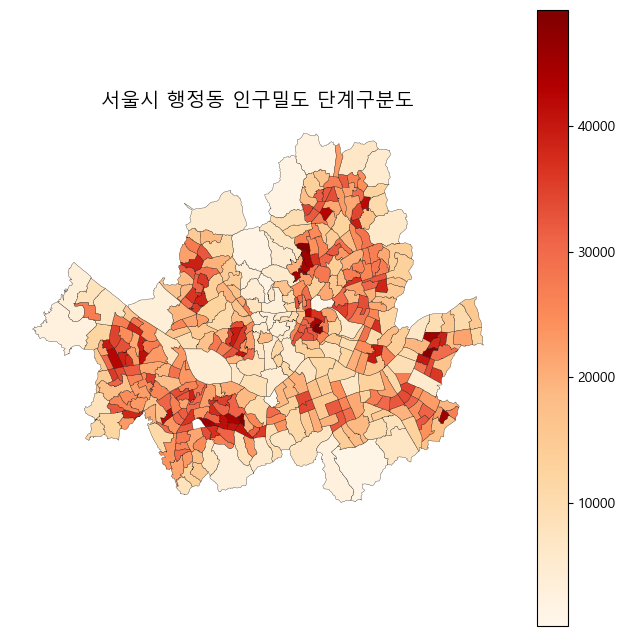

In [114]:
fig, ax = plt.subplots(figsize=(8, 8))

gdf_map.plot(
    column="pop_density",      # 색칠 기준 컬럼 (인구밀도)
    cmap="OrRd",               # 색상 팔레트 (연한색 → 진한색)
    legend=True,               # 범례 표시
    edgecolor="black",
    linewidth=0.2,
    ax=ax
)

plt.title("서울시 행정동 인구밀도 단계구분도", fontsize=14)
plt.axis("off")
plt.show()

In [115]:
pop_out = pop_df[["region_id", "region_nm", "population", "area_km2", "pop_density"]].copy()

POP_FILE = os.path.join(DATA_DIR, "pop_by_admin.csv")
pop_out.to_csv(POP_FILE, index=False, encoding="utf-8-sig")

### 4. 공간정보가 부여된 CSV 파일 전처리 : 버스 및 지하철 집계

이 단계에서는 좌표 정보를 포함한 버스정류장과 지하철역 CSV 데이터를 공간 객체로 변환한 뒤,  
행정동 경계 폴리곤과의 공간 조인을 통해 각 행정동별 시설 개수를 집계한다.  

먼저 위·경도 좌표를 이용해 Point 형태의 GeoDataFrame을 생성하고,  
행정동 경계 레이어와 동일한 좌표계(EPSG:5179)로 변환하여 공간 연산의 정확도를 확보한다.  

이후 `sjoin(within)` 연산을 통해 각 정류장·역이 어느 행정동에 속하는지를 판별하고,  
행정동 코드(region_id)를 기준으로 그룹화하여 버스정류장 수와 지하철역 수를 계산한다.  

이렇게 생성된 집계 결과는 이후 인구·면적 데이터와 결합되어  
접근성 지표(인구 1만 명당 시설 수, 면적당 시설 밀도) 계산과 공간 시각화의 기초 자료로 활용된다.

In [116]:
BUS_XLSX = os.path.join(DATA_DIR, "서울시버스정류소위치정보(20260108).xlsx")  # 서울시 버스정류소 위치 원본 엑셀 파일 경로 설정

BUS_LON_COL = "X좌표"  # 버스정류소 경도(longitude)가 들어 있는 컬럼명
BUS_LAT_COL = "Y좌표"  # 버스정류소 위도(latitude)가 들어 있는 컬럼명

In [117]:
bus_raw = pd.read_excel(BUS_XLSX)  # 버스정류소 위치 원본 엑셀 파일을 데이터프레임으로 읽기

bus_raw[BUS_LON_COL] = to_num(bus_raw[BUS_LON_COL])  # 경도(X좌표) 컬럼을 숫자형으로 변환 (문자·오류 값은 NaN 처리)
bus_raw[BUS_LAT_COL] = to_num(bus_raw[BUS_LAT_COL])  # 위도(Y좌표) 컬럼을 숫자형으로 변환

In [118]:
gdf_bus = gpd.GeoDataFrame(
    bus_raw,
    geometry=gpd.points_from_xy(bus_raw[BUS_LON_COL], bus_raw[BUS_LAT_COL]),
    crs="EPSG:4326"  
    # 경도(X좌표), 위도(Y좌표) 컬럼을 이용해 포인트 geometry 생성
    # 원본 좌표계는 위경도 좌표계(EPSG:4326)
)

# 좌표계를 미터 단위 좌표계(EPSG:5179)로 변환 - 이후 공간조인, 거리·버퍼 분석, 면적 계산을 정확하게 수행하기 위함
gdf_bus = gdf_bus.to_crs(epsg=5179)  

#### 좌표계(CRS, Coordinate Reference System)

- 지구상의 위치를 평면 좌표로 표현하기 위한 기준 체계  
- 위도·경도 좌표계와 투영 좌표계로 크게 구분됨  
- 공간 데이터 간의 좌표계가 다르면 반드시 변환 후 분석해야 함  
- 거리, 면적, 버퍼 계산의 정확도는 좌표계 선택에 크게 영향을 받음  
- GIS 분석에서는 “분석 목적에 맞는 좌표계”를 선택하는 것이 중요  

#### EPSG:4326 (WGS84, 위경도 좌표계)

- 위도(latitude)와 경도(longitude)로 위치를 표현하는 전 지구 표준 좌표계  
- 단위가 ‘도(degree)’이기 때문에 거리·면적 계산에 부적합  
- GPS, 지도 API, 대부분의 원본 위치 데이터의 기본 좌표계  
- 시각화·위치 표시에는 편리하지만 정밀 공간 분석에는 부정확  

#### EPSG:5179 (Korea 2000 / Central Belt)

- 한국 전역을 대상으로 설계된 투영 좌표계  
- 단위가 ‘미터(m)’이므로 거리·면적·버퍼 계산에 매우 정확  
- 행정구역 면적 계산, 접근성 분석, 커버리지 분석 등에 적합  
- 국내 공간 분석 실무에서 가장 많이 사용하는 표준 좌표계  

#### 4326과 5179의 핵심 차이

- 4326은 위도·경도 기반의 전 지구 좌표계, 5179는 한국 전용 투영 좌표계  
- 4326은 각도 단위라 거리·면적 계산이 부정확, 5179는 미터 단위로 정확  
- 4326은 위치 표시·데이터 교환에 적합, 5179는 분석·계산 작업에 적합  
- 공간 분석 전에는 반드시 5179 같은 투영 좌표계로 변환하는 것이 권장됨  

#### 실무 권장 원칙

- 원본 데이터 불러오기: EPSG:4326 그대로 사용  
- 공간 분석 시작 전: EPSG:5179로 통일  
- 면적·거리·버퍼 계산은 항상 투영 좌표계에서 수행 
- EPSG.io (https://epsg.io) 

In [119]:
bus_cnt = (
    gpd.sjoin(gdf_bus, gdf_admin, how="left", predicate="within")  
    # 버스정류소 포인트를 행정동 폴리곤에 공간조인 → 각 정류소에 행정동 정보 부여

    .groupby(["region_id", "region_nm"])  
    # 행정동 코드 + 행정동 이름 기준으로 그룹화

    .size()
    .reset_index(name="bus_stop_cnt")  
    # 행정동별 버스정류장 개수를 집계하여 bus_stop_cnt 컬럼으로 생성
)

bus_cnt.head()

,region_id,region_nm,bus_stop_cnt
0,11010530,사직동,33
1,11010540,삼청동,17
2,11010550,부암동,34
3,11010560,평창동,54
4,11010570,무악동,4


In [120]:
gdf_bus_map = gdf_admin.merge(
    bus_cnt[["region_id", "bus_stop_cnt"]],
    on="region_id",
    how="left"
)  
# 행정동 경계 데이터(gdf_admin)에 버스정류장 집계 결과(bus_cnt)를 행정동 코드(region_id) 기준으로 병합하여 지도용 데이터 생성

gdf_bus_map["bus_stop_cnt"] = gdf_bus_map["bus_stop_cnt"].fillna(0)  
# 버스정류장이 없는 행정동은 NaN 대신 0으로 채워서 이후 시각화·계산 오류 방지

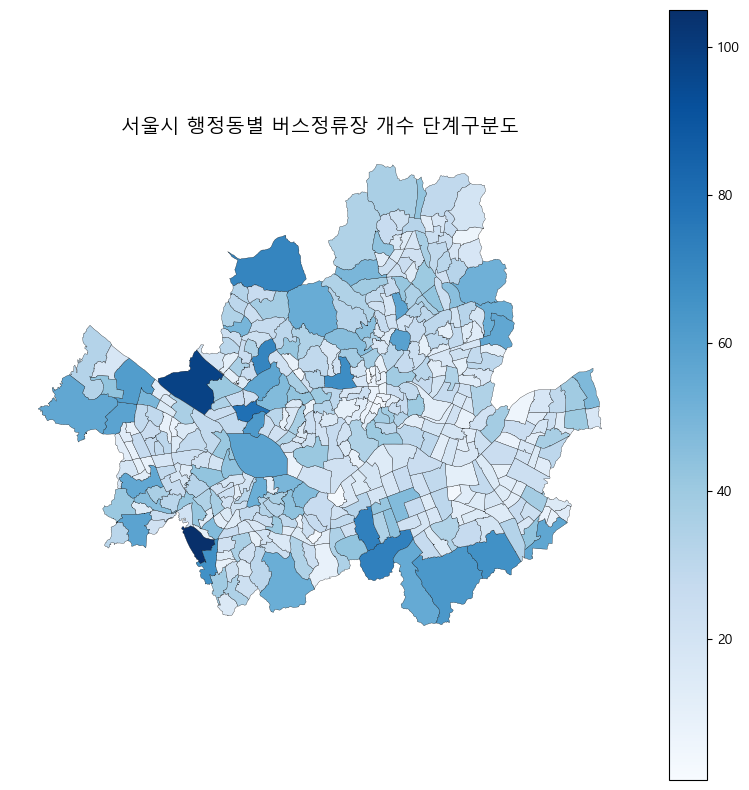

In [121]:
fig, ax = plt.subplots(figsize=(10, 10))

gdf_bus_map.plot(
    column="bus_stop_cnt",
    cmap="Blues",
    legend=True,
    edgecolor="black",
    linewidth=0.2,
    ax=ax
)

plt.title("서울시 행정동별 버스정류장 개수 단계구분도", fontsize=14)
plt.axis("off")
plt.show()

In [122]:
BUS_FILE = os.path.join(DATA_DIR, "bus_stop_cnt_by_admin.csv")  # 행정동별 버스정류장 개수 집계 결과를 저장할 CSV 파일 경로 설정

bus_cnt.to_csv(BUS_FILE, index=False, encoding="utf-8-sig")  # 버스정류장 집계 테이블을 CSV 파일로 저장 (엑셀 한글 깨짐 방지를 위해 utf-8-sig 사용)

In [123]:
SUBWAY_CSV = os.path.join(DATA_DIR, "서울교통공사_1_8호선 역사 좌표(위경도) 정보_20250814.csv") # 서울교통공사 지하철역 위치 원본 CSV 파일 경로 설정

SUB_LON_COL = "경도"  # 지하철역 경도(longitude)가 들어 있는 컬럼명
SUB_LAT_COL = "위도"  # 지하철역 위도(latitude)가 들어 있는 컬럼명

In [124]:
sub_raw = read_csv_safely(SUBWAY_CSV) # 지하철역 위치 CSV 파일을 안전하게 읽기 (UTF-8 / CP949 자동 처리)

sub_raw[SUB_LON_COL] = to_num(sub_raw[SUB_LON_COL]) # 경도 컬럼을 숫자형으로 변환 (문자·오류 값은 NaN 처리)
sub_raw[SUB_LAT_COL] = to_num(sub_raw[SUB_LAT_COL]) # 위도 컬럼을 숫자형으로 변환

In [125]:
# 지하철역 위치 데이터를 GeoDataFrame으로 생성
gdf_sub = gpd.GeoDataFrame(
    sub_raw,
    geometry=gpd.points_from_xy(sub_raw[SUB_LON_COL], sub_raw[SUB_LAT_COL]),
    crs="EPSG:4326"  
    # 경도·위도 컬럼으로 포인트 geometry 생성 (원본 좌표계: EPSG:4326)
)

In [126]:
# 좌표계를 미터 단위 좌표계(EPSG:5179)로 변환 → 거리·버퍼·공간조인 등 공간 분석을 정확하게 수행하기 위함
gdf_sub = gdf_sub.to_crs(epsg=5179)  

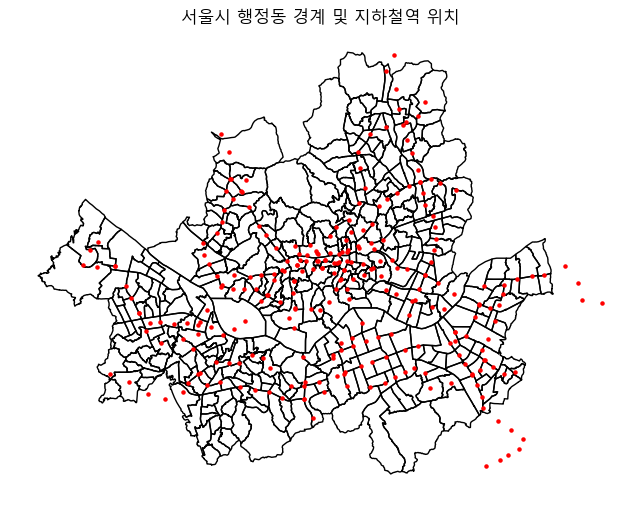

In [127]:
ax = gdf_admin.plot(edgecolor="black", facecolor="none", figsize=(8, 8))
# 행정동 경계를 먼저 그림

gdf_sub.plot(
    ax=ax,
    color="red",
    markersize=5
)
# 지하철역 포인트를 빨간 점으로 표시

plt.title("서울시 행정동 경계 및 지하철역 위치")
plt.axis("off")
plt.show()

In [128]:
sub_cnt = (
    gpd.sjoin(gdf_sub, gdf_admin, how="left", predicate="within")  
    # 지하철역 포인트(gdf_sub)를 행정동 폴리곤(gdf_admin)에 공간조인 → 각 지하철역이 속한 행정동 코드·이름 정보 부여

    .groupby(["region_id", "region_nm"])  # 행정동 코드(region_id)와 행정동 이름(region_nm) 기준으로 그룹화

    .size()
    .reset_index(name="subway_cnt")  # 행정동별 지하철역 개수를 집계하여 subway_cnt 컬럼으로 생성
)

In [129]:
SUBWAY_FILE = os.path.join(DATA_DIR, "subway_cnt_by_admin.csv")  # 행정동별 지하철역 개수 집계 결과를 저장할 CSV 파일 경로 설정

sub_cnt.to_csv(SUBWAY_FILE, index=False, encoding="utf-8-sig")  # 지하철역 집계 테이블을 CSV 파일로 저장 (엑셀 한글 깨짐 방지를 위해 utf-8-sig 인코딩 사용)

### 5. 가공 데이터 병합 및 파생지표

이 단계에서는 앞에서 개별적으로 가공한 인구, 버스, 지하철, 면적 데이터를  
행정동 코드(region_id)를 기준으로 하나의 통합 테이블로 병합한다.  

속성 분석용 DataFrame과 지도 시각화를 위한 GeoDataFrame을 분리하여 구성함으로써,  
통계 분석과 공간 시각화를 각각 효율적으로 수행할 수 있도록 설계한다.  

병합 과정에서 발생할 수 있는 자료형 불일치와 결측값 문제를 정리하고,  
시설이 존재하지 않는 행정동은 개수를 0으로 보정하여 분석 안정성을 확보한다.  

이후 인구 규모 차이를 보정하기 위해 인구 1만 명당 버스 정류장 수,  
인구 1만 명당 지하철역 수와 같은 표준화 지표를 생성한다.  

이러한 파생지표는 단순 개수 비교를 넘어 지역 간 접근성 격차를 정량적으로 비교하고,  
교통 취약 지역을 선별하기 위한 핵심 분석 지표로 활용된다.

In [130]:
pop_df    = read_csv_safely(POP_FILE)  # 행정동별 인구 집계 결과 CSV 파일을 안전하게 읽어오기
bus_df    = read_csv_safely(BUS_FILE)  # 행정동별 버스정류장 개수 집계 결과 CSV 파일을 읽어오기
subway_df = read_csv_safely(SUBWAY_FILE)  # 행정동별 지하철역 개수 집계 결과 CSV 파일을 읽어오기
area_df   = read_csv_safely(AREA_FILE)  # 행정동별 면적 계산 결과 CSV 파일을 읽어오기

In [131]:
pop_n = pop_df[["region_id", "population", "pop_density"]].copy()  # 인구 데이터에서 행정동 코드(region_id)와 총인구(population) 컬럼만 선택하여 복사
bus_n = bus_df[["region_id", "bus_stop_cnt"]].copy()  # 버스 집계 데이터에서 행정동 코드(region_id)와 버스정류장 개수(bus_stop_cnt)만 추출
sub_n = subway_df[["region_id", "subway_cnt"]].copy() # 지하철 집계 데이터에서 행정동 코드(region_id)와 지하철역 개수(subway_cnt)만 추출
area_n = area_df[["region_id", "area_km2"]].copy()  # 면적 데이터에서 행정동 코드(region_id)와 행정동 면적(area_km2)만 선택

In [132]:
df = (
    pop_n
    # 인구 데이터(pop_n)를 기준으로 버스 집계 데이터(bus_n)를 행정동 코드(region_id)로 병합
    .merge(bus_n, on="region_id", how="left")

    # 병합된 결과에 지하철 집계 데이터(sub_n)를 다시 행정동 코드(region_id) 기준으로 병합
    .merge(sub_n, on="region_id", how="left")

    # 마지막으로 면적 데이터(area_n)를 행정동 코드(region_id) 기준으로 병합하여
    # 인구 + 버스 + 지하철 + 면적 정보를 모두 포함한 속성 테이블 생성
    .merge(area_n, on="region_id", how="left")
)

df.head()

,region_id,population,pop_density,bus_stop_cnt,subway_cnt,area_km2
0,11010530.0,9139,7894.296069,33.0,2.0,1.157671
1,11010540.0,2353,1592.891665,17.0,NaN,1.477188
2,11010550.0,9170,4034.237058,34.0,NaN,2.273044
3,11010560.0,17270,1931.625746,54.0,NaN,8.940655
4,11010570.0,7714,20891.250816,4.0,1.0,0.369245


In [133]:
df["bus_stop_cnt"] = df["bus_stop_cnt"].fillna(0)  
# 버스정류장 데이터가 없는 행정동의 결측값(NaN)을 0으로 채워 이후 집계·밀도 계산·시각화 과정에서 오류가 발생하지 않도록 처리

df["subway_cnt"] = df["subway_cnt"].fillna(0)  
# 지하철역이 하나도 없는 행정동의 결측값을 0으로 채워 시설 개수 계산과 단계구분도 시각화를 안정적으로 수행하기 위함

In [134]:
# gdf_admin 쪽 region_id를 문자열 타입으로 통일하고 앞뒤 공백 제거
gdf_admin["region_id"] = gdf_admin["region_id"].astype(str).str.strip()

# df 쪽 region_id가 float(예: 11010530.0)로 들어온 경우를 대비한 정규화 과정
df["region_id"] = (
    pd.to_numeric(df["region_id"], errors="coerce")   # region_id를 숫자로 변환 (변환 불가 값은 NaN)
    .astype("Int64")                                  # 결측치를 허용하는 정수형으로 변환
    .astype(str)                                      # 다시 문자열 타입으로 변환
    .str.replace("<NA>", "", regex=False)             # 결측값 표시(<NA>) 문자열 제거
    .str.strip()                                      # 앞뒤 공백 제거
)

# 행정동 경계(gdf_admin)와 속성 테이블(df)을 행정동 코드(region_id) 기준으로 병합
gdf_map = gdf_admin.merge(df, on="region_id", how="left")

# 병합 결과 확인
gdf_map.head()

,region_id,region_nm,geometry,population,pop_density,bus_stop_cnt,subway_cnt,area_km2
0,11240750,잠실4동,"POLYGON ((966144.947 1947247.39, 966140.973 19...",21197.0,27189.565582,10.0,3.0,0.779601
1,11240780,잠실7동,"POLYGON ((962306.123 1944876.429, 962298.368 1...",9340.0,12919.607135,4.0,1.0,0.722932
2,11240790,잠실2동,"POLYGON ((963373.433 1945897.333, 963372.972 1...",34722.0,12932.856874,11.0,0.0,2.684790
3,11240770,잠실6동,"POLYGON ((964764.987 1947265.422, 964790.647 1...",16531.0,10970.650559,15.0,2.0,1.506839
4,11240580,방이2동,"POLYGON ((965792.751 1946532.439, 965878.771 1...",26913.0,34986.235084,13.0,0.0,0.769245


In [135]:
gdf_map["bus_per_10k"] = gdf_map["bus_stop_cnt"] / (gdf_map["population"] / 10000)  # 행정동별 버스정류장 개수를 인구 1만 명 단위로 표준화한 지표 생성
gdf_map["subway_per_10k"] = gdf_map["subway_cnt"] / (gdf_map["population"] / 10000)  # 행정동별 지하철역 개수를 인구 1만 명 단위로 표준화한 지표 생성
gdf_map.head()

,region_id,region_nm,geometry,population,pop_density,bus_stop_cnt,subway_cnt,area_km2,bus_per_10k,subway_per_10k
0,11240750,잠실4동,"POLYGON ((966144.947 1947247.39, 966140.973 19...",21197.0,27189.565582,10.0,3.0,0.779601,4.717649,1.415295
1,11240780,잠실7동,"POLYGON ((962306.123 1944876.429, 962298.368 1...",9340.0,12919.607135,4.0,1.0,0.722932,4.282655,1.070664
2,11240790,잠실2동,"POLYGON ((963373.433 1945897.333, 963372.972 1...",34722.0,12932.856874,11.0,0.0,2.684790,3.168020,0.000000
3,11240770,잠실6동,"POLYGON ((964764.987 1947265.422, 964790.647 1...",16531.0,10970.650559,15.0,2.0,1.506839,9.073861,1.209848
4,11240580,방이2동,"POLYGON ((965792.751 1946532.439, 965878.771 1...",26913.0,34986.235084,13.0,0.0,0.769245,4.830379,0.000000


In [136]:
# bus_per_10k 값을 분위수 기준으로 5개 구간으로 나누어 단계 변수 생성
gdf_map["bus_class"] = pd.qcut(
    gdf_map["bus_per_10k"],
    q=5,
    labels=["매우 낮음", "낮음", "보통", "높음", "매우 높음"]
)

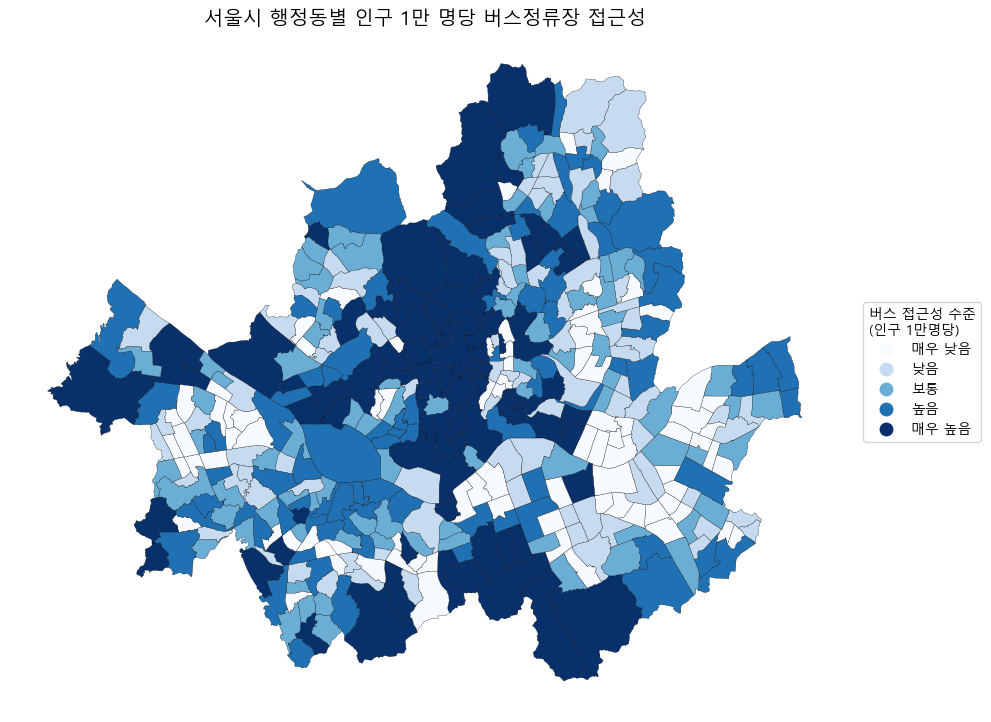

In [137]:
fig, ax = plt.subplots(figsize=(10, 10))

gdf_map.plot(
    column="bus_class",
    cmap="Blues",
    edgecolor="black",
    linewidth=0.2,
    legend=True,
    ax=ax,
    legend_kwds={
        "title": "버스 접근성 수준\n(인구 1만명당)",
        "loc": "center left",
        "bbox_to_anchor": (1.02, 0.5)   # 범례를 지도 오른쪽 바깥에 배치
    }
)

plt.title("서울시 행정동별 인구 1만 명당 버스정류장 접근성", fontsize=14)
plt.axis("off")
plt.tight_layout()
plt.show()

In [138]:
OUT_GPKG = os.path.join(OUT_DIR, "eda_map_dong.gpkg")

gdf_map.to_file(OUT_GPKG, layer="eda_map_dong", driver="GPKG")  
# 행정동 경계 + 인구 + 버스 + 지하철 + 파생지표를 포함한 공간 데이터 저장
# QGIS, GeoPandas에서 바로 다시 불러와 지도 시각화 가능

# OUT_SHP = os.path.join(OUT_DIR, "eda_map_dong.shp")
# gdf_map.to_file(OUT_SHP, encoding="utf-8")  
# 행정동별 분석 결과를 Shapefile 형식으로 저장

#### Shapefile(.shp)와 GeoPackage(.gpkg) 요약 비교

Shapefile과 GeoPackage는 공간 데이터를 저장하는 대표적인 형식이지만 구조와 기능에서 큰 차이를 가진다.

Shapefile은 하나의 레이어가 여러 개의 파일(.shp, .shx, .dbf, .prj 등)로 구성되어 관리가 불편하고,  
컬럼 이름 10자 제한과 한글 깨짐 문제 등 구조적 제약이 많다.  
다만 오래된 표준 형식으로 대부분의 GIS 소프트웨어에서 널리 지원된다.

GeoPackage는 하나의 파일 안에 모든 정보를 저장하는 최신 OGC 표준 형식으로,  
여러 레이어를 동시에 저장할 수 있고 컬럼 길이 제한이 없으며 UTF-8 인코딩을 기본 지원한다.  
대용량 데이터 처리 성능도 우수하고 관리가 매우 편리하다.

#### 활용 권장

- **Shapefile**: 구형 시스템 호환이 필요하거나 단순 레이어 전달용  
- **GeoPackage**: 강의·연구·실무 전반, 한글 데이터 포함, 복합 분석 결과 저장용  

#### 한 줄 요약

- Shapefile은 호환성은 뛰어나지만 제약이 많은 구형 포맷이고,  
- GeoPackage는 최신 표준으로 관리와 분석에 훨씬 적합한 포맷이다.

### 6. EDA(Exploratory Data Analysis)

#### “버스 접근성이 낮은 동은 지하철 접근성도 좋지 않은가?”

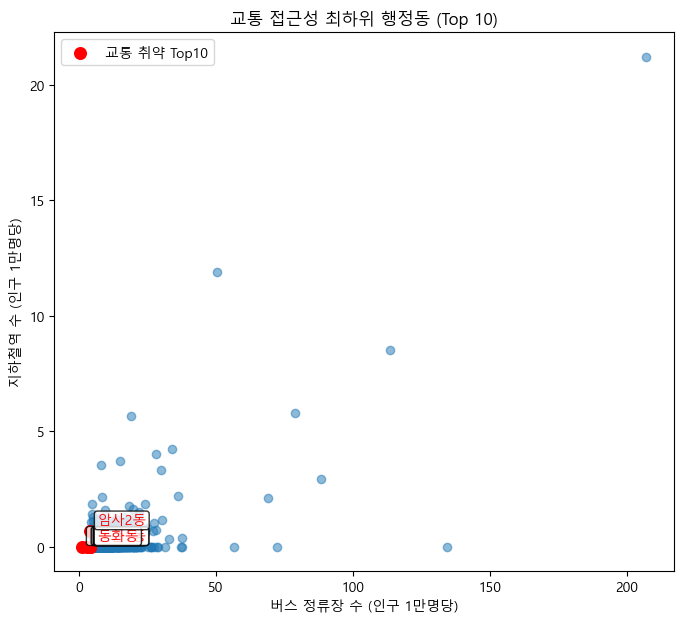

In [139]:
# bus + subway 접근성이 모두 가장 낮은 행정동 10개 선택 (버스 접근성 → 지하철 접근성 순으로 오름차순 정렬 후 상위 7개)
target_top = gdf_map.sort_values(
    ["bus_per_10k", "subway_per_10k"]
).head(10)

# 전체 행정동 산점도 생성
plt.figure(figsize=(8, 7))
plt.scatter(
    gdf_map["bus_per_10k"], 
    gdf_map["subway_per_10k"], 
    alpha=0.5                    # 점 투명도 조절 (겹침 완화)
)

# 교통 취약 Top 7 행정동만 빨간색으로 강조 표시
plt.scatter(
    target_top["bus_per_10k"],
    target_top["subway_per_10k"],
    color="red",                 # 취약 지역 색상
    s=70,                        # 점 크기
    label="교통 취약 Top10"       # 범례 표시 이름
)

# 취약 지역 10개에 대해 행정동 이름 라벨 표시
for _, row in target_top.iterrows():
    plt.annotate(
        row["region_nm"],        # 표시할 텍스트: 행정동 이름
        (row["bus_per_10k"], row["subway_per_10k"]),  # 텍스트 위치 (해당 점 위치)
        xytext=(5, 5),           # 점에서 약간 떨어진 위치에 표시
        textcoords="offset points",
        fontsize=10,
        color="red",
        bbox=dict(               # 텍스트 배경 박스 설정
            boxstyle="round,pad=0.2", 
            fc="white", 
            alpha=0.8
        )
    )

plt.xlabel("버스 정류장 수 (인구 1만명당)") # x축 라벨 설정
plt.ylabel("지하철역 수 (인구 1만명당)") # y축 라벨 설정
plt.title("교통 접근성 최하위 행정동 (Top 10)") # 그래프 제목 설정
plt.legend() # 범례 표시
plt.show() # 그래프 출력

In [140]:
# 버스·지하철 접근성이 가장 낮은 행정동 10개 선택
target_top10 = gdf_map.sort_values(
    ["bus_per_10k", "subway_per_10k"]   # 버스 → 지하철 접근성 기준으로 오름차순 정렬
).head(10)                             # 최하위 10개 행정동 추출

# 분석에 필요한 핵심 컬럼만 선택하여 결과 확인
target_top10[[
    "region_nm",        # 행정동 이름
    "population",       # 총 인구
    "bus_stop_cnt",     # 버스 정류장 개수
    "bus_per_10k",      # 인구 1만 명당 버스 정류장 수
    "subway_cnt",       # 지하철역 개수
    "subway_per_10k"    # 인구 1만 명당 지하철역 수
]]

,region_nm,population,bus_stop_cnt,bus_per_10k,subway_cnt,subway_per_10k
22,창신2동,8456.0,1.0,1.182592,0.0,0.000000
306,사당4동,13729.0,4.0,2.913541,0.0,0.000000
2,잠실2동,34722.0,11.0,3.168020,0.0,0.000000
209,중계4동,18827.0,7.0,3.718064,0.0,0.000000
142,목3동,20871.0,8.0,3.833070,0.0,0.000000
360,거여2동,23160.0,9.0,3.886010,0.0,0.000000
315,암사1동,32998.0,13.0,3.939633,0.0,0.000000
380,둔촌1동,32883.0,13.0,3.953411,0.0,0.000000
397,동화동,9871.0,4.0,4.052274,0.0,0.000000
376,암사2동,14613.0,6.0,4.105933,1.0,0.684322


#### “인구 밀도가 높은데 버스 접근성은 충분한가?”

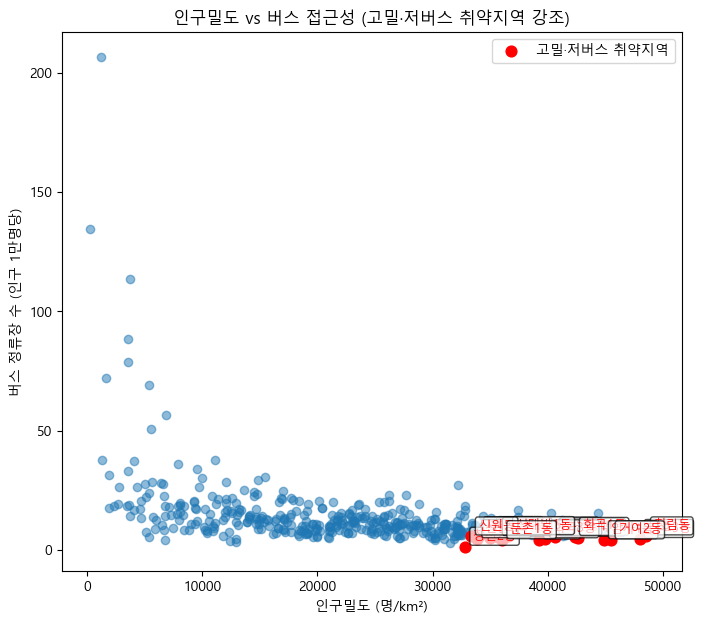

In [141]:
plt.figure(figsize=(8, 7))   # 그래프 크기 설정

# 전체 행정동 산점도 그리기 (인구밀도 vs 버스 접근성)
plt.scatter(
    gdf_map["pop_density"],     # x축: 인구밀도
    gdf_map["bus_per_10k"],     # y축: 인구 1만명당 버스 정류장 수
    alpha=0.5                  # 점 투명도 (겹침 완화)
)

# 기준값 설정
high_density = gdf_map["pop_density"].quantile(0.8)   # 인구밀도 상위 20% 기준값
low_bus      = gdf_map["bus_per_10k"].quantile(0.1)   # 버스 접근성 하위 10% 기준값

# 취약 후보 지역 선택: 인구밀도는 높고 + 버스 접근성은 낮은 행정동
target2 = gdf_map[
    (gdf_map["pop_density"] >= high_density) &
    (gdf_map["bus_per_10k"] <= low_bus)
]

# 취약 지역만 빨간색으로 강조 표시
plt.scatter(
    target2["pop_density"],
    target2["bus_per_10k"],
    color="red",
    s=60,
    label="고밀·저버스 취약지역"
)

# 취약 지역에 행정동 이름 라벨 표시
for _, row in target2.iterrows():
    plt.annotate(
        row["region_nm"],                     # 표시할 텍스트: 행정동 이름
        (row["pop_density"], row["bus_per_10k"]),  # 해당 점 위치
        xytext=(5, 5),                        # 점에서 약간 떨어진 위치에 표시
        textcoords="offset points",
        fontsize=9,
        color="red",
        bbox=dict(                            # 텍스트 배경 박스 설정
            boxstyle="round,pad=0.2",
            fc="white",
            alpha=0.7
        )
    )

plt.xlabel("인구밀도 (명/km²)")
plt.ylabel("버스 정류장 수 (인구 1만명당)") # 축 라벨 설정
plt.title("인구밀도 vs 버스 접근성 (고밀·저버스 취약지역 강조)") # 그래프 제목 설정
plt.legend() # 범례 표시
plt.show() # 그래프 출력

In [142]:
# 취약 지역 후보 중 분석에 필요한 핵심 컬럼만 선택하여 리스트 구성
target2_list = target2[[
    "region_id",        # 행정동 코드
    "region_nm",        # 행정동 이름
    "population",       # 총 인구
    "area_km2",         # 면적(km²)
    "pop_density",      # 인구밀도(명/km²)
    "bus_stop_cnt",     # 버스 정류장 개수
    "bus_per_10k"       # 인구 1만 명당 버스 정류장 수
]]

# 버스 접근성 낮은 순 → 인구밀도 높은 순으로 정렬하여 우선순위 설정
target2_list = target2_list.sort_values(
    ["bus_per_10k", "pop_density"],   # 정렬 기준: 버스 접근성, 인구밀도
    ascending=[True, False]           # 버스는 오름차순(낮을수록 우선), 밀도는 내림차순
)

# 상위 5개 취약 지역 미리 확인
target2_list.head(10)

,region_id,region_nm,population,area_km2,pop_density,bus_stop_cnt,bus_per_10k
22,11010680,창신2동,8456.0,0.257321,32861.684266,1.0,1.182592
142,11150530,목3동,20871.0,0.531464,39270.772784,8.0,3.833070
360,11240540,거여2동,23160.0,0.509223,45481.074553,9.0,3.886010
315,11250720,암사1동,32998.0,0.734907,44900.890860,13.0,3.939633
380,11250700,둔촌1동,32883.0,0.911467,36076.986810,13.0,3.953411
271,11160580,화곡3동,20741.0,0.521483,39773.143164,9.0,4.339231
256,11150580,신월2동,20551.0,0.606373,33891.682811,9.0,4.379349
309,11250630,천호3동,26936.0,0.561117,48004.269898,12.0,4.455004
4,11240580,방이2동,26913.0,0.769245,34986.235084,13.0,4.830379
91,11020670,황학동,14012.0,0.328391,42668.624122,7.0,4.995718


### [공간 파생변수 생성] 닿는 곳과 닿지 않는 곳을 공간으로 분리하다  
#### 버퍼 기반 커버 / 비커버 분석 (GeoPandas)

[문제 인식]에서는 행정동 단위로 버스·지하철 정류장 개수를 집계하고, 인구 대비 접근성 지표(bus_per_10k, subway_per_10k)와  
인구밀도(pop_density)를 생성하였다.

2강에서는 같은 질문을 거리 기반 접근성 관점에서 다시 다룬다.  

- 버스정류장 또는 지하철역으로부터 일정 거리(버퍼) 안에 포함되는 공간은 커버 영역(covered)으로 정의하고,  
- 그 범위에 포함되지 않는 공간은 비커버 영역(uncovered)으로 정의한다.  

본 강의에서는 버스정류장 300m, 지하철역 500m를 유효 보행 접근 반경으로 설정하여  
버스 버퍼와 지하철 버퍼를 각각 생성한 뒤, 이를 통합 커버리지(버스 ∪ 지하철)로 결합한다.

이후 서울시 행정동 폴리곤에서 통합 커버리지를 차집합 연산으로 제거하여 각 행정동 내부의 교통 비커버 취약 공간을 산출한다.

마지막으로, 인구밀도, 비커버 비율, 버스 접근성을 종합한 취약 점수를 계산하여  
인구는 많지만 교통 접근성이 낮은 후보 지역 중 개선 우선 Top 5 행정동을 선정하고,  
이를 지도 시각화 및 공간 파일(GPKG)로 저장한다.

#### 보행 접근권 설정 기준

본 프로젝트에서는 대중교통 보행 접근권 기준에 따라 버스 정류장은 **300m**, 지하철역은 **500m**를 유효 접근 반경으로 설정하였다.  
이는 국내 교통계획 및 TOD 가이드라인에서 제시하는 도보 3~5분(버스), 도보 7~10분(지하철) 기준을 반영한 것이다.

In [143]:
# 버스정류장 포인트(geometry)만 따로 복사해서, 버퍼 분석용 GeoDataFrame을 만든다
gdf_bus_buf = gdf_bus[["geometry"]].copy()

# 버스정류장 각 포인트를 중심으로 반경 300m 버퍼(원 형태의 폴리곤)를 생성한다
gdf_bus_buf["geometry"] = gdf_bus_buf.geometry.buffer(300)
gdf_bus_buf.head()

,geometry
0,"POLYGON ((950344 1947894.926, 950342.556 19478..."
1,"POLYGON ((946796.08 1950765.089, 946794.635 19..."
2,"POLYGON ((942377.438 1953060.363, 942375.993 1..."
3,"POLYGON ((955064.414 1952394.075, 955062.97 19..."
4,"POLYGON ((955844.456 1953458.003, 955843.011 1..."


In [144]:
# 지하철역 포인트(geometry)만 복사해서, 버퍼 분석용 GeoDataFrame을 만든다
gdf_sub_buf = gdf_sub[["geometry"]].copy()

# 지하철역 각 포인트를 중심으로 반경 500m 버퍼 폴리곤을 생성한다
gdf_sub_buf["geometry"] = gdf_sub_buf.geometry.buffer(500)
gdf_sub_buf.head()

,geometry
0,"POLYGON ((953910.048 1950553.661, 953907.641 1..."
1,"POLYGON ((954170.369 1951710.506, 954167.961 1..."
2,"POLYGON ((954855.232 1952440.413, 954852.825 1..."
3,"POLYGON ((955648.287 1952461.163, 955645.879 1..."
4,"POLYGON ((956514.464 1952516.66, 956512.057 19..."


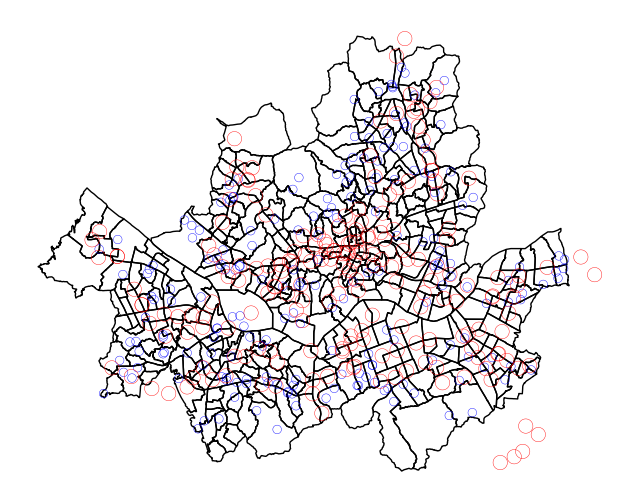

In [145]:
# 행정동 경계를 먼저 배경으로 그린다
ax = gdf_admin.plot(edgecolor="black", facecolor="none", figsize=(8, 8))

# 버스 버퍼 중 일부(200개)만 파란색 테두리로 표시 전체를 다 그리면 너무 겹쳐서 보기 어려우므로 샘플만 시각화
gdf_bus_buf.sample(200, random_state=7).plot(
    ax=ax, 
    facecolor="none", 
    edgecolor="blue", 
    linewidth=0.3
)

# 지하철 버퍼 중 일부(200개)만 빨간색 테두리로 표시
gdf_sub_buf.sample(200, random_state=7).plot(
    ax=ax, 
    facecolor="none", 
    edgecolor="red", 
    linewidth=0.3
)

# 축과 격자를 숨기고 지도만 출력
plt.axis("off")
plt.show()

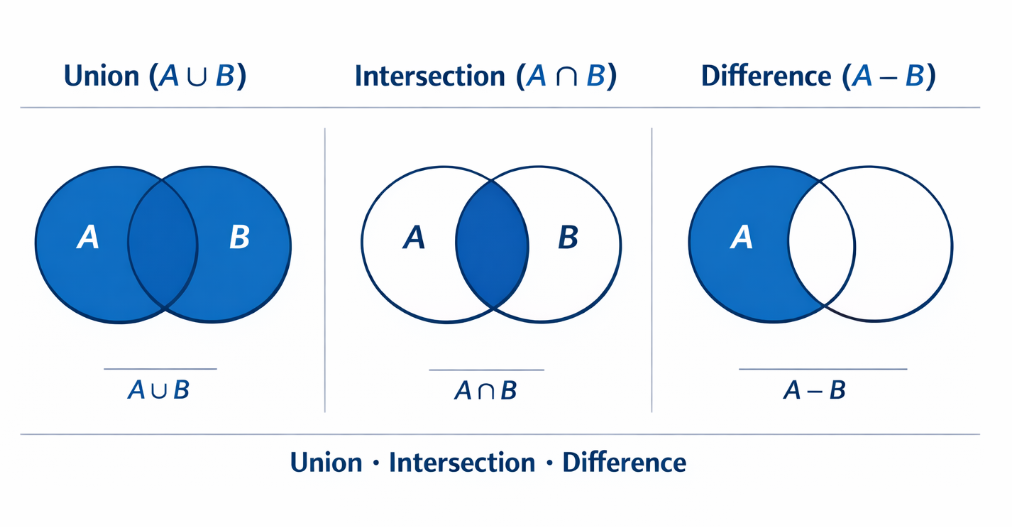

#### 공간 연산 기본 개념 (Union · Intersection · Difference)

- **Union (합집합)**  
  `A.union(B)` : 두 영역 A와 B를 모두 합친 전체 영역 (A ∪ B)

- **Intersection (교집합)**  
  `A.intersection(B)` : 두 영역이 서로 겹치는 공통 부분 (A ∩ B)

- **Difference (차집합)**  
  `A.difference(B)` : A 영역에서 B 영역을 제거하고 남은 부분 (A − B)

이 연산들은 접근성 분석, 커버리지 계산, 비커버(사각지대) 영역 추출 등에 사용된다.

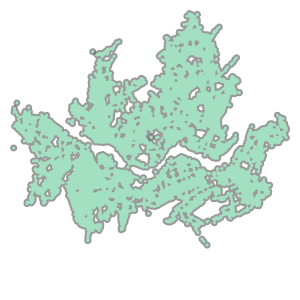

In [146]:
# 버스 버퍼 여러 개를 하나의(멀티) 폴리곤으로 모두 합친다
bus_union_geom = gdf_bus_buf.geometry.union_all()
bus_union_geom

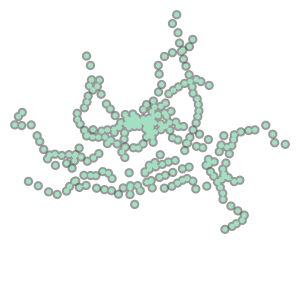

In [147]:
# 지하철 버퍼 여러 개도 동일하게 하나의 커버리지 폴리곤으로 합친다
sub_union_geom = gdf_sub_buf.geometry.union_all()
sub_union_geom

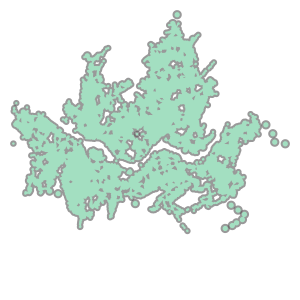

In [148]:
# 최종 통합 커버리지 생성 / 버스 커버리지 ∪ 지하철 커버리지를 합쳐 "버스나 지하철 중 하나라도 닿는 전체 영역"을 만든다
coverage_union_geom = bus_union_geom.union(sub_union_geom)
coverage_union_geom

In [149]:
# 통합 커버리지(버스 ∪ 지하철) geometry를 하나의 GeoDataFrame으로 감싼다
# coverage_union_geom은 단일(또는 멀티) Polygon 객체이므로, 이후 plot, overlay, to_file 같은 GeoPandas 함수에서 쓰기 위해 GeoDataFrame 형태로 변환

gdf_coverage_union = gpd.GeoDataFrame(
    {
        "name": ["bus_or_sub_coverage_union"],  # 레이어 구분용 이름(식별자 컬럼)
        "geometry": [coverage_union_geom]       # 통합 커버리지 폴리곤(버스∪지하철 영향권)
    },
    crs=5179   # 좌표계: EPSG:5179 (미터 단위, 이후 면적·차집합 연산에 필수)
)

# 생성된 통합 커버리지 레이어를 바로 출력해서 형태 확인
gdf_coverage_union

,name,geometry
0,bus_or_sub_coverage_union,"MULTIPOLYGON (((939431.813 1941821.529, 939408..."


In [150]:
# 기존 분석 결과(gdf_map)를 복사해서 취약지역 분석용 데이터프레임 생성
gdf_vuln = gdf_map.copy()

# 각 행정동의 전체 면적(m²) 계산
gdf_vuln["admin_area_m2"] = gdf_vuln.geometry.area
gdf_vuln.sort_values("admin_area_m2", ascending=False).head()

,region_id,region_nm,geometry,population,pop_density,bus_stop_cnt,subway_cnt,area_km2,bus_per_10k,subway_per_10k,bus_class,admin_area_m2
89,11220680,내곡동,"POLYGON ((963300.76 1941906.941, 963279.798 19...",16764.0,1320.087928,63.0,0.0,12.699154,37.580530,0.000000,매우 높음,1.269915e+07
120,11120710,진관동,"POLYGON ((952334.023 1959056.272, 952247.134 1...",54036.0,4675.706744,71.0,1.0,11.556756,13.139389,0.185062,높음,1.155676e+07
277,11160690,공항동,"POLYGON ((939179.436 1951902.541, 939232.017 1...",29271.0,2696.652313,56.0,1.0,10.854570,19.131564,0.341635,매우 높음,1.085457e+07
394,11090740,우이동,"POLYGON ((956677.661 1965103.514, 956676.035 1...",19576.0,1850.320257,34.0,0.0,10.579790,17.368206,0.000000,매우 높음,1.057979e+07
7,11010560,평창동,"POLYGON ((953709.234 1959266.832, 953709.205 1...",17270.0,1931.625746,54.0,0.0,8.940655,31.268095,0.000000,매우 높음,8.940655e+06


In [151]:
# 행정동 폴리곤에서 통합 커버리지를 빼서 비커버(닿지 않는) 영역 생성
gdf_vuln["uncovered_geom"] = gdf_vuln.geometry.difference(coverage_union_geom)
gdf_vuln.head()

,region_id,region_nm,geometry,population,pop_density,bus_stop_cnt,subway_cnt,area_km2,bus_per_10k,subway_per_10k,bus_class,admin_area_m2,uncovered_geom
0,11240750,잠실4동,"POLYGON ((966144.947 1947247.39, 966140.973 19...",21197.0,27189.565582,10.0,3.0,0.779601,4.717649,1.415295,매우 낮음,7.796005e+05,POLYGON EMPTY
1,11240780,잠실7동,"POLYGON ((962306.123 1944876.429, 962298.368 1...",9340.0,12919.607135,4.0,1.0,0.722932,4.282655,1.070664,매우 낮음,7.229322e+05,"POLYGON ((962298.368 1944877.305, 962278.322 1..."
2,11240790,잠실2동,"POLYGON ((963373.433 1945897.333, 963372.972 1...",34722.0,12932.856874,11.0,0.0,2.684790,3.168020,0.000000,매우 낮음,2.684790e+06,"MULTIPOLYGON (((961845.209 1946345.54, 961844...."
3,11240770,잠실6동,"POLYGON ((964764.987 1947265.422, 964790.647 1...",16531.0,10970.650559,15.0,2.0,1.506839,9.073861,1.209848,낮음,1.506839e+06,"MULTIPOLYGON (((963993.575 1947177.132, 963993..."
4,11240580,방이2동,"POLYGON ((965792.751 1946532.439, 965878.771 1...",26913.0,34986.235084,13.0,0.0,0.769245,4.830379,0.000000,매우 낮음,7.692454e+05,POLYGON EMPTY


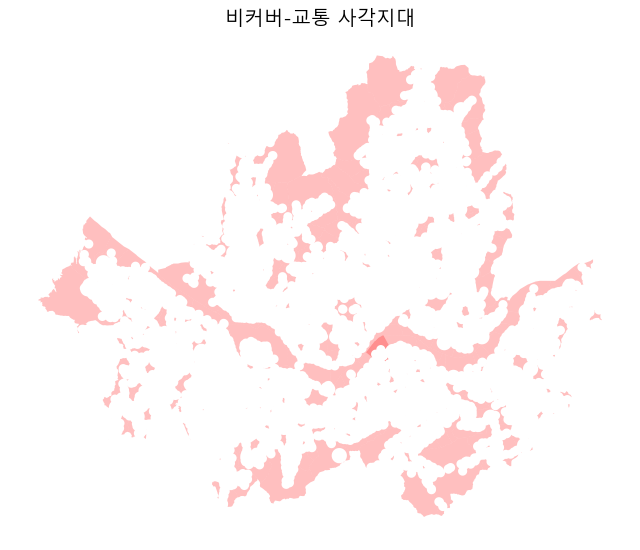

In [152]:
# uncovered_geom 컬럼을 geometry로 바꿔서 ‘비커버 영역 전용’ GeoDataFrame 생성
gdf_uncovered = gpd.GeoDataFrame(
    gdf_vuln.drop(columns=["geometry"]).rename(columns={"uncovered_geom": "geometry"}),
    crs=gdf_vuln.crs
)

# 지도 출력용 Figure와 축 생성
fig, ax = plt.subplots(figsize=(8, 8))

# 비커버(교통 사각지대) 영역을 빨간색 음영으로 표시
gdf_uncovered.plot(ax=ax, color="red", alpha=0.25, edgecolor="none")

# 제목과 축 설정
plt.title("비커버-교통 사각지대", fontsize=14)
plt.axis("off")
plt.show()

In [153]:
# 비커버 영역의 면적(m²) 계산
gdf_vuln["uncovered_area_m2"] = gdf_vuln["uncovered_geom"].area
gdf_vuln[["region_nm", "uncovered_area_m2"]].sort_values("uncovered_area_m2", ascending=False).head()

,region_nm,uncovered_area_m2
394,우이동,9.185161e+06
89,내곡동,8.137624e+06
277,공항동,8.052031e+06
120,진관동,6.923270e+06
70,도봉1동,6.849521e+06


In [154]:
# 행정동 전체 면적 대비 비커버 면적 비율 계산
# np.where(조건, 조건이 True일 때 값, 조건이 False일 때 값)
gdf_vuln["uncovered_ratio"] = np.where(
    gdf_vuln["admin_area_m2"] > 0,                              # 면적이 0이 아닌 경우만 계산
    gdf_vuln["uncovered_area_m2"] / gdf_vuln["admin_area_m2"],  # 비커버 면적 / 전체 면적
    0.0
)
gdf_vuln[["region_nm", "uncovered_ratio"]].sort_values("uncovered_ratio", ascending=False).head()

,region_nm,uncovered_ratio
394,우이동,0.868180
70,도봉1동,0.811068
313,남현동,0.762126
277,공항동,0.741810
226,상계3·4동,0.724833


In [155]:
# uncovered_ratio 컬럼의 결측값(NaN)을 0으로 채우고, 값이 0보다 작거나 1보다 큰 경우를 방지하기 위해 0~1 범위로 제한
gdf_vuln["uncovered_ratio"] = gdf_vuln["uncovered_ratio"].fillna(0.0).clip(0, 1)

In [156]:
# 0~1 범위로 정규화하는 Min-Max 스케일링 함수
def _minmax(s):
    s = s.astype(float)                       # 입력 값을 실수형으로 변환
    if s.max() == s.min():                    # 모든 값이 동일하면
        return pd.Series(np.zeros(len(s)), index=s.index)  # 전부 0으로 반환
    return (s - s.min()) / (s.max() - s.min())  # (값 - 최소) / (최대 - 최소) → 0~1 정규화

In [157]:
# 인구밀도와 비커버 비율을 0~1 범위로 정규화하여 서로 단위가 다른 지표들을 동일한 스케일에서 비교 가능하게 만든다
gdf_vuln["pop_norm"] = _minmax(gdf_vuln["pop_density"])      # 인구밀도 정규화 (값이 클수록 취약도 증가)
gdf_vuln["unc_norm"] = _minmax(gdf_vuln["uncovered_ratio"]) # 비커버 비율 정규화 (값이 클수록 취약도 증가)

In [158]:
# 버스정류장 + 지하철역 개수는 적을수록 취약하므로, 정규화한 값을 1에서 빼서 '정류장이 적을수록 큰 값'이 되도록 역정규화
gdf_vuln["bus_sub_inv_norm"] = 1 - _minmax(gdf_vuln["bus_stop_cnt"] + gdf_vuln["subway_cnt"])

In [159]:
# 가중치 설정 (각 지표가 취약도에 미치는 중요도 비율)
# - 인구밀도: 사람이 많이 사는 지역일수록 개선 우선순위가 높다고 가정 → default : 0.33
# - 비커버 비율: 교통이 닿지 않는 면적 비중이 클수록 취약 → default : 0.33
# - 버스정류장 + 지하철역 수: 버스 정류장 + 지하철역이 적을수록 취약 → default : 0.33
W_POP = 0.33
W_UNC = 0.33
W_BUS = 0.33

# 세 지표(인구밀도, 비커버 비율, 버스 접근성)를 가중합하여 최종 '교통 취약 점수(vulnerability_score)' 계산
gdf_vuln["vulnerability_score"] = (
    gdf_vuln["pop_norm"] * W_POP +        # 인구밀도 영향
    gdf_vuln["unc_norm"] * W_UNC +        # 비커버 비율 영향
    gdf_vuln["bus_sub_inv_norm"] * W_BUS      # 버스 접근성 영향(역정규화)
)

In [160]:
# 계산된 취약 점수(vulnerability_score)를 기준으로 값이 큰 순서(가장 취약한 지역부터)로 전체 행정동을 정렬
ranking = gdf_vuln.sort_values("vulnerability_score", ascending=False)

In [161]:
# 상위 20개 후보
candidate_top20 = ranking[[
    "region_id", "region_nm",
    "population", "pop_density",
    "bus_stop_cnt", "subway_cnt", 
    "uncovered_ratio", "vulnerability_score"
]]

candidate_top20.head(20)

,region_id,region_nm,population,pop_density,bus_stop_cnt,subway_cnt,uncovered_ratio,vulnerability_score
311,11210540,청림동,14418.0,48556.289843,8.0,0.0,0.000000,0.633637
313,11210630,남현동,17469.0,5328.235197,9.0,0.0,0.762126,0.628902
209,11110640,중계4동,18827.0,12401.646831,7.0,0.0,0.617849,0.628010
309,11250630,천호3동,26936.0,48004.269898,12.0,0.0,0.000584,0.617568
306,11200660,사당4동,13729.0,31501.363130,4.0,0.0,0.212988,0.612246
360,11240540,거여2동,23160.0,45481.074553,9.0,0.0,0.002932,0.610887
315,11250720,암사1동,32998.0,44900.890860,13.0,0.0,0.042232,0.609344
256,11150580,신월2동,20551.0,33891.682811,9.0,0.0,0.204016,0.609228
164,11070680,망우3동,15746.0,16371.071403,11.0,0.0,0.527425,0.607814
376,11250580,암사2동,14613.0,6725.908810,6.0,1.0,0.661962,0.606533


In [162]:
# 최종 개선 Top 5
final_top5 = candidate_top20.head(5)
final_top5

,region_id,region_nm,population,pop_density,bus_stop_cnt,subway_cnt,uncovered_ratio,vulnerability_score
311,11210540,청림동,14418.0,48556.289843,8.0,0.0,0.000000,0.633637
313,11210630,남현동,17469.0,5328.235197,9.0,0.0,0.762126,0.628902
209,11110640,중계4동,18827.0,12401.646831,7.0,0.0,0.617849,0.628010
309,11250630,천호3동,26936.0,48004.269898,12.0,0.0,0.000584,0.617568
306,11200660,사당4동,13729.0,31501.363130,4.0,0.0,0.212988,0.612246


In [163]:
# 취약도 Top5 행정동의 region_id 목록 (문자열로 통일)
top5_ids = ["11210540", "11210630", "11110640", "11250630", "11200660"]  # 청림동, 남현동, 중계4동, 천호3동, 사당4동

# 전체 취약도 결과(gdf_vuln)에서 region_id가 Top5 목록에 포함된 행정동만 필터링하여 추출
gdf_top5 = gdf_vuln[gdf_vuln["region_id"].astype(str).isin(top5_ids)].copy()

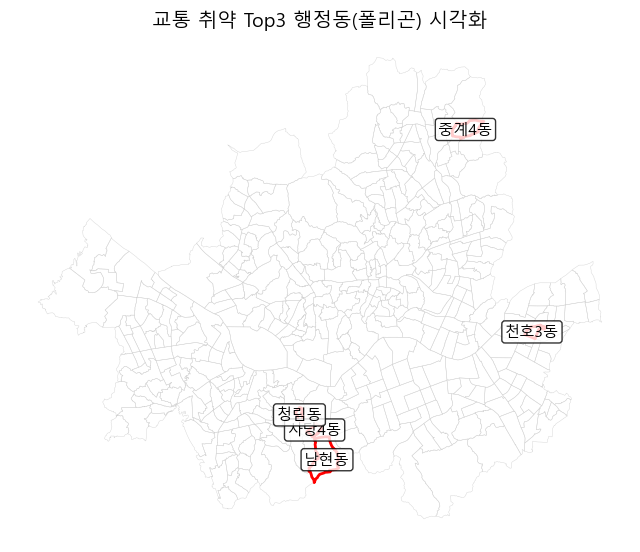

In [164]:
# 지도 시각화용 Figure와 축 생성
fig, ax = plt.subplots(figsize=(8, 8))

# 배경으로 서울시 전체 행정동 경계를 연하게 표시
gdf_admin.plot(ax=ax, facecolor="none", edgecolor="lightgray", linewidth=0.3)

# Top3 취약 행정동 폴리곤만 빨간색 테두리로 강조
gdf_top5.plot(ax=ax, facecolor="none", edgecolor="red", linewidth=2)

# 각 행정동 중심 위치에 행정동 이름 라벨 표시
for _, row in gdf_top5.iterrows():
    p = row.geometry.representative_point()  # 폴리곤 내부 대표 점 계산
    ax.text(
        p.x, p.y, row["region_nm"],
        fontsize=11, ha="center", va="center",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.8)
    )

# 지도 제목 설정
plt.title("교통 취약 Top3 행정동(폴리곤) 시각화", fontsize=14)

# 축 표시 제거
plt.axis("off")

# 결과 출력
plt.show()

In [165]:
# Top5 행정동에서 비커버 영역(uncovered_geom)만 따로 꺼내어 geometry 컬럼으로 지정한 새로운 GeoDataFrame 생성
gdf_top5_uncovered = gpd.GeoDataFrame(
    gdf_top5.drop(columns=["geometry"])            # 기존 행정동 geometry 컬럼 제거
            .rename(columns={"uncovered_geom": "geometry"}),  # 비커버 영역을 geometry로 사용
    crs=gdf_top5.crs                               # 좌표계는 원본과 동일하게 유지
)

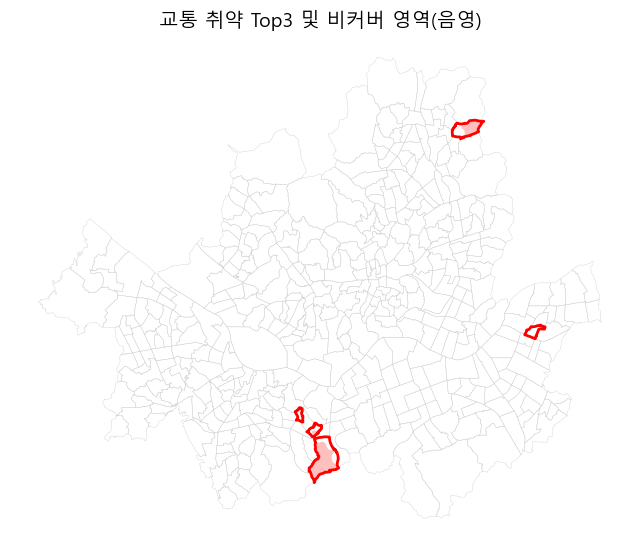

In [166]:
# Figure와 지도 축 생성
fig, ax = plt.subplots(figsize=(8, 8))

# 배경: 서울시 전체 행정동 경계 (연한 회색)
gdf_admin.plot(ax=ax, facecolor="none", edgecolor="lightgray", linewidth=0.3)

# Top5 취약 행정동 경계 강조 (빨간 테두리)
gdf_top5.plot(ax=ax, facecolor="none", edgecolor="red", linewidth=2)

# Top5 행정동 내부의 비커버 영역을 빨간 음영으로 표시
gdf_top5_uncovered.plot(ax=ax, color="red", alpha=0.25, edgecolor="none")

# 제목 설정
plt.title("교통 취약 Top3 및 비커버 영역(음영)", fontsize=14)

# 축 제거
plt.axis("off")

# 지도 출력
plt.show()

### GeoPandas와 Folium의 차이

GeoPandas와 Folium은 모두 지도를 그릴 수 있지만, 역할과 목적이 다르다.

GeoPandas는 공간 데이터를 처리하고 분석하기 위한 라이브러리로, 좌표계 변환, 버퍼, 교차, 차집합, 공간조인 등 다양한 공간 연산을 수행할 수 있다.  
Matplotlib 기반의 정적 지도를 생성하며, 분석 과정 확인과 논문·보고서용 지도 제작에 적합하다.

Folium은 웹 기반 인터랙티브 지도를 만들기 위한 라이브러리로, 확대·축소, 이동, 레이어 켜고 끄기 등 사용자 상호작용이 가능하다.  
공간 연산 기능은 없으며, 분석 결과를 시각적으로 보여주고 공유하는 데 주로 사용된다.

In [167]:
%pip install folium

In [168]:
# Step 1: 교통 접근성만 기준으로 추출된 행정동 이름 목록
stage1_names = target_top10["region_nm"].tolist()

# Step 2: 교통 + 인구를 함께 고려해 추출된 행정동 이름 목록
stage2_names = target2_list["region_nm"].tolist()

# Step 3: 교통 + 인구 + 커버리지까지 모두 고려한 최종 후보 Top10 행정동 이름 목록
stage3_names = candidate_top20.head(10)["region_nm"].tolist()

In [169]:
# Step 1에서 선택된 행정동 이름 목록에 해당하는 폴리곤만 추출
gdf_stage1 = gdf_admin[gdf_admin["region_nm"].isin(stage1_names)].copy()

# Step 2에서 선택된 행정동 이름 목록에 해당하는 폴리곤만 추출
gdf_stage2 = gdf_admin[gdf_admin["region_nm"].isin(stage2_names)].copy()

# Step 3(최종)에서 선택된 행정동 이름 목록에 해당하는 폴리곤만 추출
gdf_stage3 = gdf_admin[gdf_admin["region_nm"].isin(stage3_names)].copy()

In [170]:
import os                                    # 환경변수를 설정하기 위해 불러옴
import folium                                # 인터랙티브 지도를 만들기 위해 불러옴
from folium.plugins import MarkerCluster     # 버스 정류장을 클러스터로 묶어 표시하기 위해 불러옴

# ── 좌표계 변환 (EPSG:5179 등 → WGS84) ──────────────────────────────────────
gdf_admin_wgs  = gdf_admin.to_crs(epsg=4326)   # 행정동 경계를 WGS84(위경도)로 변환
gdf_stage1_wgs = gdf_stage1.to_crs(epsg=4326)  # Step1 필터 결과를 WGS84로 변환
gdf_stage2_wgs = gdf_stage2.to_crs(epsg=4326)  # Step2 필터 결과를 WGS84로 변환
gdf_stage3_wgs = gdf_stage3.to_crs(epsg=4326)  # Step3 최종 후보를 WGS84로 변환
gdf_sub_wgs    = gdf_sub.to_crs(epsg=4326)     # 지하철역 포인트를 WGS84로 변환
gdf_bus_wgs    = gdf_bus.to_crs(epsg=4326)     # 버스 정류장 포인트를 WGS84로 변환

# ── 지도 기본 설정 ────────────────────────────────────────────────────────────
m = folium.Map(
    location=[37.55, 126.98],  # 서울 중심 좌표(위도, 경도)를 지도 중심으로 설정
    zoom_start=11,             # 초기 줌 레벨을 설정 (숫자가 클수록 확대)
    tiles=None                 # 기본 타일을 비활성화하고 아래에서 직접 추가
)

# ── OSM 타일 레이어 ───────────────────────────────────────────────────────────
# ※ HTML 파일로 저장 후 로컬에서 열면 Referer 없음으로 403이 발생할 수 있음
#   노트북 안에서 m 으로 바로 출력하거나, 저장 후 'python -m http.server'로 열면 정상 작동
folium.TileLayer(
    tiles="https://{s}.tile.openstreetmap.org/{z}/{x}/{y}.png",  # OSM 표준 타일 URL
    attr="© <a href='https://www.openstreetmap.org/copyright'>OpenStreetMap</a> contributors",  # 저작권 표기
    name="OpenStreetMap",      # 레이어 컨트롤에 표시될 이름
    overlay=False,             # 배경지도이므로 base layer로 지정
    control=True,              # LayerControl 패널에 표시
    max_zoom=19                # OSM의 최대 줌 레벨을 지정
).add_to(m)

# ── 전체 행정동 경계 ──────────────────────────────────────────────────────────
folium.GeoJson(
    gdf_admin_wgs,             # 서울 전체 행정동 경계 GeoDataFrame을 넘김
    name="전체 행정동",          # 레이어 컨트롤에 표시될 이름
    style_function=lambda x: {
        "fillColor":   "#aaaaaa",  # 폴리곤 내부 채움 색상을 연한 회색으로 지정
        "fillOpacity": 0.05,       # 내부를 거의 투명하게 설정
        "color":       "#888888",  # 경계선 색상을 중간 회색으로 지정
        "weight":      0.8         # 경계선 두께를 얇게 설정
    }
).add_to(m)

# ── Step1: 교통 조건만 통과한 행정동 (파란 점선) ──────────────────────────────
folium.GeoJson(
    gdf_stage1_wgs,            # Step1 결과 GeoDataFrame을 넘김
    name="Step1: 교통만",       # 레이어 컨트롤에 표시될 이름
    style_function=lambda x: {
        "fillColor":   "#4a90d9",  # 내부를 파란색 계열로 채움
        "fillOpacity": 0.15,       # 내부를 살짝 비치게 설정
        "color":       "#1a5fb4",  # 경계선 색상을 진한 파란색으로 지정
        "weight":      2.5,        # 경계선 두께를 중간으로 설정
        "dashArray":   "8 5"       # 점선 패턴(선 길이 8, 간격 5)을 적용
    }
).add_to(m)

# ── Step2: 교통 + 인구 조건 통과 (주황 점선) ──────────────────────────────────
folium.GeoJson(
    gdf_stage2_wgs,            # Step2 결과 GeoDataFrame을 넘김
    name="Step2: 교통 + 인구",  # 레이어 컨트롤에 표시될 이름
    style_function=lambda x: {
        "fillColor":   "#f5a623",  # 내부를 주황색 계열로 채움
        "fillOpacity": 0.2,        # 내부를 조금 더 진하게 설정
        "color":       "#d07000",  # 경계선 색상을 진한 주황색으로 지정
        "weight":      2.5,        # 경계선 두께를 중간으로 설정
        "dashArray":   "8 5"       # 점선 패턴을 동일하게 적용
    }
).add_to(m)

# ── Step3: 최종 후보 행정동 (빨간 실선, 가장 강조) ────────────────────────────
folium.GeoJson(
    gdf_stage3_wgs,                      # Step3 최종 후보 GeoDataFrame을 넘김
    name="Step3: 교통 + 인구 + 커버리지",  # 레이어 컨트롤에 표시될 이름
    style_function=lambda x: {
        "fillColor":   "#e74c3c",  # 내부를 붉은색으로 채워 강조
        "fillOpacity": 0.25,       # 내부를 반투명하게 설정
        "color":       "#c0392b",  # 경계선 색상을 진한 빨간색으로 지정
        "weight":      3.5         # 경계선을 가장 두껍게 설정해 강조
    }
).add_to(m)

# ── 지하철역 마커 ─────────────────────────────────────────────────────────────
subway_group = folium.FeatureGroup(name="지하철역")  # 지하철역을 담을 레이어 그룹을 만듬
subway_group.add_to(m)                               # 그룹을 지도에 등록

for _, row in gdf_sub_wgs.iterrows():                # 지하철역 레코드를 하나씩 순회
    if row.geometry is None or row.geometry.is_empty:  # 유효하지 않은 geometry는 건너뜀
        continue

    # Point / MultiPoint 모두 단일 리스트로 정규화
    pts = [row.geometry] if row.geometry.geom_type == "Point" else list(row.geometry.geoms)

    for pt in pts:                                   # 각 포인트를 순회하며 마커를 추가
        folium.CircleMarker(
            location=[pt.y, pt.x],                  # 위도(y), 경도(x) 순으로 좌표를 지정
            radius=6,                                # 원 마커의 반지름(px)을 설정
            color="#1a5fb4",                         # 외곽선 색상을 진한 파란색으로 지정
            fill=True,                               # 원 내부를 채움
            fill_color="#4a90d9",                    # 내부 채움 색상을 밝은 파란색으로 지정
            fill_opacity=0.9,                        # 내부 투명도를 거의 불투명하게 설정
            weight=2,                                # 외곽선 두께를 설정
            tooltip=str(row.get("name", "지하철역")),  # 마우스 호버 시 역 이름을 표시
            popup=folium.Popup(                      # 클릭 시 팝업 창을 표시
                str(row.get("name", "지하철역")),
                max_width=180
            )
        ).add_to(subway_group)                       # 마커를 지하철역 그룹에 추가

# ── 버스 정류장 클러스터 마커 ─────────────────────────────────────────────────
cluster = MarkerCluster(name="버스 정류장")  # 버스 정류장을 클러스터로 묶는 레이어 생성
cluster.add_to(m)                            # 클러스터 레이어를 지도에 등록

for _, row in gdf_bus_wgs.iterrows():        # 버스 정류장 레코드를 하나씩 순회
    if row.geometry is None or row.geometry.is_empty:  # 유효하지 않은 geometry는 건너뜀
        continue

    # Point / MultiPoint 모두 단일 리스트로 정규화
    pts = [row.geometry] if row.geometry.geom_type == "Point" else list(row.geometry.geoms)

    for pt in pts:                           # 각 포인트를 순회하며 마커를 추가
        folium.CircleMarker(
            location=[pt.y, pt.x],          # 위도(y), 경도(x) 순으로 좌표를 지정
            radius=4,                        # 지하철역보다 작은 반지름을 설정
            color="#27ae60",                 # 외곽선 색상을 진한 초록색으로 지정
            fill=True,                       # 원 내부를 채움
            fill_color="#2ecc71",            # 내부 채움 색상을 밝은 초록색으로 지정
            fill_opacity=0.85,               # 내부 투명도를 설정
            weight=1.5,                      # 외곽선 두께를 설정
            tooltip=str(row.get("name", "버스 정류장")),  # 마우스 호버 시 정류장 이름을 표시
            popup=folium.Popup(              # 클릭 시 팝업 창을 표시
                str(row.get("name", "버스 정류장")),
                max_width=180
            )
        ).add_to(cluster)                    # 마커를 버스 정류장 클러스터에 추가

# ── 레이어 컨트롤 및 저장 ─────────────────────────────────────────────────────
folium.LayerControl(collapsed=False).add_to(m)  # 레이어를 켜고 끌 수 있는 컨트롤을 추가
m.save("seoul_steps_compare.html")              # 지도를 HTML 파일로 저장

### [과업의 한계] 단계별 교통 취약 지역 비교 인사이트  
- 이번 분석에서는 동일한 서울을 대상으로  
- ① 교통만, ② 교통 + 인구, ③ 교통 + 인구 + 직선거리 기반 커버리지를 순차적으로 적용하여 취약 지역을 비교하였다.
- 각 단계는 지표를 단순히 추가하는 것이 아니라, 어떤 정보가 실제로 추가되는지를 검증하는 과정이었다.

#### Step 1: 교통만 기준
- 정류장 개수만 고려할 경우, 외곽·저밀 지역이 취약 지역으로 다수 선정됨  
- 실제 이용 수요가 거의 없는 지역까지 취약으로 과대평가되는 한계 존재  
→ 공급량(인프라 수)만으로는 정책 우선순위를 설정하기 어려움  

#### Step 2: 교통 + 인구 기준
- 인구를 함께 고려하면 취약 지역이 주거 밀집 지역 중심으로 이동  
- “정류장이 적으면서 수요가 큰 지역”이 선별되어 정책적 의미가 증가  
→ 공급과 수요를 함께 고려할 때 취약지역 분포가 달라짐  

#### Step 3: 교통 + 인구 + 직선거리 기반 커버리지 기준
- 정류장 + 역 반경(예: 500m) 커버리지를 추가하여 접근성을 보정  
- 그러나 커버리지 지표는 정류장 + 역 분포와 높은 공간적 상관성을 보임  
- 즉, 정류장이 많은 지역은 커버도 넓고, 정류장이 적은 지역은 커버도 좁은 구조가 반복됨  
- 이로 인해, 지표를 추가했음에도 공간 분포가 크게 달라지지 않거나  
- 정류장 수와 커버리지가 유사한 패턴을 공유하는 **공간적 다중공선성(spatial multicollinearity)** 문제가 발생함  
→ 단순 직선거리 기반 보정만으로는 실제 접근성 차이를 충분히 설명하기 어려움 

### 종합 해석 및 다음 단계
- 취약 지역은 지표 설계 방식에 따라 크게 달라질 수 있음  
- 그러나 정류장 수와 직선거리 기반 커버리지는 동일한 공간 구조를 공유하기 때문에 설명력이 중복될 가능성이 있음  
- 특히 직선거리 기반 접근성은 실제 도로 구조, 단절 구간, 우회 경로 등을 반영하지 못한다는 한계가 존재한다.
- 따라서 보다 현실적인 교통 접근성 분석을 위해서는 단순 반경이 아닌, 실제 이동 경로를 반영한 접근성 평가 방식이 필요하다.
→ 다음 단계에서는 이러한 한계를 보완하기 위해 실제 보행 경로를 고려한 분석으로 확장한다.

In [171]:
final_names = ["청림동", "남현동"]

# gdf_admin(전체 행정동 폴리곤)에서 데모 대상 행정동만 필터링
gdf_demo = gdf_admin[gdf_admin["region_nm"].isin(final_names)].copy()

### 📌 공간적 다중공선성 (Spatial Multicollinearity)

**공간적 다중공선성**이란,  
서로 다른 변수처럼 보이지만 **공간적으로 거의 동일한 분포 패턴을 공유하여**  
실질적으로는 **중복된 정보를 제공하는 현상**을 의미한다.

즉,

- 정류장 수가 많은 지역은 커버리지도 높게 나타나고  
- 정류장 수가 적은 지역은 커버리지도 낮게 나타나는 경우처럼  

두 지표가 같은 공간 구조를 반복할 때 발생한다.

이 경우,  
지표를 추가했음에도 분석의 설명력이 크게 증가하지 않으며,  
취약지역 구분력이 제한될 수 있다.

In [172]:
os.makedirs(OUT_DIR, exist_ok=True)

# gdf_vuln에서 데모 대상만
gdf_demo = gdf_vuln[gdf_vuln["region_nm"].isin(final_names)].copy()
gdf_demo["region_id"] = gdf_demo["region_id"].astype(str)

# -------------------------------------------------
# 1) (원래 행정동 폴리곤)만 저장: geometry만 남기고 uncovered_geom은 제거
# -------------------------------------------------
gdf_demo_admin = gdf_demo.copy()

# uncovered_geom이 'geometry 타입'이면 to_file에서 문제
if "uncovered_geom" in gdf_demo_admin.columns:
    gdf_demo_admin = gdf_demo_admin.drop(columns=["uncovered_geom"])

OUT_GPKG_ADMIN = os.path.join(OUT_DIR, "demo_admin.gpkg")
if os.path.exists(OUT_GPKG_ADMIN):
    os.remove(OUT_GPKG_ADMIN)

gdf_demo_admin.to_file(OUT_GPKG_ADMIN, layer="admin", driver="GPKG")
print("행정동(원래 폴리곤) 저장:", OUT_GPKG_ADMIN)

# -------------------------------------------------
# 2) (비커버 폴리곤)만 저장: uncovered_geom을 geometry로 바꾸고 원래 geometry는 제거
# -------------------------------------------------
gdf_demo_uncovered = gdf_demo.copy()

# 원래 행정동 geometry 제거(여러 geometry 컬럼 방지)
gdf_demo_uncovered = gdf_demo_uncovered.drop(columns=["geometry"])

# uncovered_geom -> geometry로 교체
gdf_demo_uncovered = gpd.GeoDataFrame(
    gdf_demo_uncovered.rename(columns={"uncovered_geom": "geometry"}),
    crs=gdf_demo.crs
)

OUT_GPKG_UNC = os.path.join(OUT_DIR, "demo_uncovered.gpkg")
if os.path.exists(OUT_GPKG_UNC):
    os.remove(OUT_GPKG_UNC)

gdf_demo_uncovered.to_file(OUT_GPKG_UNC, layer="uncovered", driver="GPKG")
print("비커버(차집합 결과) 저장:", OUT_GPKG_UNC)

행정동(원래 폴리곤) 저장: c:\_jupyter_workspace\practice\gis_session\outputs\demo_admin.gpkg
비커버(차집합 결과) 저장: c:\_jupyter_workspace\practice\gis_session\outputs\demo_uncovered.gpkg
